In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [10]:
df = pd.read_csv("Mall_Customers.xls")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

In [13]:
X = df.drop("CustomerID", axis=1)

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

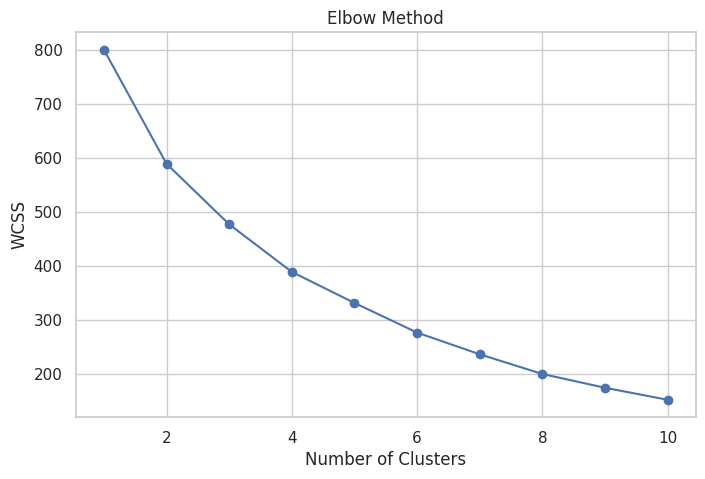

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [18]:
df["Cluster"].value_counts()

,count
Cluster,
3,54
2,43
0,39
4,35
1,29


In [19]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.461538,32.692308,86.538462,82.128205
1,165.482759,0.448276,36.482759,89.517241,18.000000
2,73.651163,0.000000,49.813953,49.232558,40.069767
3,52.814815,0.407407,24.907407,39.722222,61.203704
4,84.685714,1.000000,55.714286,53.685714,36.771429


In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [22]:
print(pca.explained_variance_ratio_)

print("Total Variance:",
      pca.explained_variance_ratio_.sum())

[0.33690046 0.26230645]
Total Variance: 0.5992069019819846


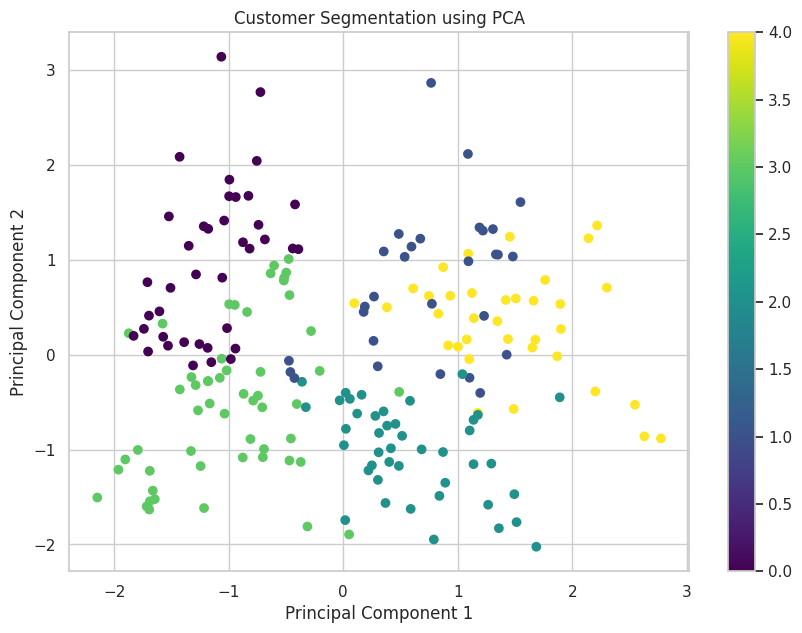

In [23]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Customer Segmentation using PCA")

plt.colorbar(scatter)

plt.show()

In [24]:
cluster_profile

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.461538,32.692308,86.538462,82.128205
1,165.482759,0.448276,36.482759,89.517241,18.000000
2,73.651163,0.000000,49.813953,49.232558,40.069767
3,52.814815,0.407407,24.907407,39.722222,61.203704
4,84.685714,1.000000,55.714286,53.685714,36.771429


Cluster 0 – High Value Customers
• High income
• High spending
• Reward with premium memberships and exclusive offers

Cluster 1 – Budget Customers
• Low income
• Low spending
• Offer discounts and seasonal promotions

Cluster 2 – Potential Customers
• Medium income
• Medium spending
• Personalized recommendations can increase purchases

Cluster 3 – Careful Spenders
• High income
• Low spending
• Encourage spending through loyalty rewards

Cluster 4 – Young Enthusiasts
• Lower income
• High spending
• Promote trendy and affordable products